# ResNet-50 + Wavelet Late Fusion — Breast Cancer Classification
Based on: Mohanty & Das, *"An Improved Convolutional Network for Breast Cancer Detection"* (IEEE ISAC3 2025).

## Which version of the paper this implements

Section II.A of the paper says, in plain text:

> "In parallel, multiscale texture characteristics are extracted from the images using the discrete
> wavelet transform (DWT). From the wavelet coefficients, statistical descriptors like energy, entropy,
> and contrast are calculated. To provide a complete feature representation, these features are
> concatenated with ResNet features."

That's a **fully specified, implementable** architecture: compute wavelet-based scalar descriptors once
per image, concatenate them with ResNet50's pooled feature vector, classify. This notebook implements
exactly that — unlike the separate `ResNet50_WResNet_PerStageFusion.ipynb` notebook, which chases the
paper's Fig. 1/Fig. 3 diagrams (wavelet fusion at every ResNet stage) and has to guess at a lot of
unspecified detail to do so.

## What is (and isn't) precisely specified here

- **Preprocessing** — precisely specified: grayscale -> 3x3 median filter -> resize -> scale to [0,1].
- **Energy** — the paper gives an explicit formula (sum of squared coefficients, "quadratic sum").
- **Entropy and contrast** — named but never given a formula. This notebook uses standard, commonly-used
  definitions (Shannon entropy of the normalized coefficient-energy distribution; variance as contrast),
  clearly separated from the parts of the paper that are exact.
- **Decomposition level / how many features** — not specified. This notebook uses a single-level 2D DWT
  (one detail level: horizontal/vertical/diagonal sub-bands), producing **9 scalar features**
  (3 sub-bands x {energy, entropy, contrast}). Deeper decomposition or a different feature count is an
  easy change if you'd rather match something else.
- **Classes / image size** — kept as before: 224x224 input, your existing 3-class
  Benign / Malignant / Normal folder structure.
- **Loss** — sparse categorical cross-entropy (paper's stated loss), integer labels.

This version is much cheaper computationally than the per-stage notebook: one small DWT per image
(done once in the data generator, not inside the model graph), vs. a full 5-level decomposition run
inside `tf.py_function` at every stage on every batch.


In [1]:
# ==========================================================
# DATASET PATH
# ==========================================================
print("start")

import os

balanced_dataset = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

print("Balanced dataset ready")


start
Balanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
)

# tensorflow_addons is not used -- F1/Precision/Recall are custom classes below that
# work directly with the sparse integer labels the paper's loss function requires.

print("done1")


start
done1


In [4]:
# ==========================================================
# CONFIGURATION
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3                  # Benign / Malignant / Normal
BATCH_SIZE = 32
EPOCHS = 150

MEDIAN_FILTER_SIZE = 3           # paper: "3x3" adaptive median filter

WAVELET_NAME = "db1"             # Haar -- paper does not name a wavelet family
WAVELET_FEATURES_PER_SUBBAND = 3 # energy, entropy, contrast
NUM_WAVELET_FEATURES = 3 * WAVELET_FEATURES_PER_SUBBAND   # cH, cV, cD -> 9 scalars

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print("done1")


start
done1


In [5]:
# ==========================================================
# PREPROCESSING (paper: "Data Pre-processing")
# ==========================================================
# grayscale -> 3x3 median filter -> resize -> scale to [0,1]

def preprocess_mammogram(img_bgr, image_size=IMAGE_SIZE, filter_size=MEDIAN_FILTER_SIZE):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, image_size, interpolation=cv2.INTER_AREA)
    gray = cv2.medianBlur(gray, filter_size)
    gray01 = gray.astype(np.float32) / 255.0
    return gray01


# ==========================================================
# WAVELET FEATURE VECTOR (paper Section II.A: energy, entropy, contrast)
# ==========================================================
# Single-level 2D DWT -> 3 detail sub-bands (H, V, D) -> 3 scalar descriptors each -> 9-d vector.
# Energy has an explicit formula in the paper (sum of squared coefficients). Entropy and contrast
# are standard, clearly-flagged choices (the paper only describes them in words).

def wavelet_feature_vector(gray01, wavelet=WAVELET_NAME):
    cA, (cH, cV, cD) = pywt.dwt2(gray01, wavelet)

    feats = []
    for sub in (cH, cV, cD):
        # Energy: sum of squared coefficients (paper's formula)
        energy = float(np.sum(sub ** 2))

        # Entropy: Shannon entropy of the normalized squared-coefficient distribution
        p = (sub ** 2).ravel()
        p = p / (p.sum() + 1e-8)
        entropy = float(-np.sum(p * np.log2(p + 1e-8)))

        # Contrast: variance of the sub-band coefficients
        contrast = float(np.var(sub))

        feats.extend([energy, entropy, contrast])

    return np.array(feats, dtype=np.float32)


print("Preprocessing + wavelet feature-vector functions ready.")
print("Wavelet feature vector length:", NUM_WAVELET_FEATURES)


Preprocessing + wavelet feature-vector functions ready.
Wavelet feature vector length: 9


In [6]:
# ==========================================================
# DATA GENERATOR -- two inputs: image, wavelet feature vector; integer labels
# ==========================================================

class MammogramGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = {name: i for i, name in enumerate(self.class_names)}

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_indices[cls])

        self.labels = np.array(self.labels, dtype=np.int32)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelet = np.zeros((len(batch_idx), NUM_WAVELET_FEATURES), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx),), dtype=np.int32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            gray01 = preprocess_mammogram(img_bgr, self.image_size)
            batch_images[i] = np.repeat(gray01[..., None], 3, axis=-1)
            batch_wavelet[i] = wavelet_feature_vector(gray01)
            batch_labels[i] = self.labels[fi]

        return (batch_images, batch_wavelet), batch_labels

    @property
    def classes(self):
        return self.labels


train_generator = MammogramGenerator(train_dir, shuffle=True)
val_generator = MammogramGenerator(val_dir, shuffle=False)
test_generator = MammogramGenerator(test_dir, shuffle=False)

print("Classes found:", train_generator.class_names)
print("Train / Val / Test sizes:",
      len(train_generator.filepaths), len(val_generator.filepaths), len(test_generator.filepaths))

# NOTE: wavelet features have very different scales than the ResNet branch's pooled
# activations. Consider standardizing them (subtract mean / divide by std computed
# on the training set) before concatenation if training is unstable -- the paper
# doesn't mention normalization, so it's left out by default to stay literal.


Classes found: ['Benign', 'Malignant', 'Normal']
Train / Val / Test sizes: 18000 2965 2943


In [7]:
# ==========================================================
# CUSTOM SPARSE-LABEL METRICS (macro F1 / Precision / Recall)
# ==========================================================

class _SparseMacroPRF1Base(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name, **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true_oh = tf.one_hot(y_true, self.num_classes)
        y_pred_oh = tf.one_hot(tf.argmax(y_pred, axis=-1), self.num_classes)
        self.tp.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh, axis=0))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0))

    def reset_state(self):
        for v in (self.tp, self.fp, self.fn):
            v.assign(tf.zeros_like(v))

    def _precision(self):
        return self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())

    def _recall(self):
        return self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())


class SparseMacroPrecision(_SparseMacroPRF1Base):
    def __init__(self, num_classes, name="precision", **kwargs):
        super().__init__(num_classes, name=name, **kwargs)

    def result(self):
        return tf.reduce_mean(self._precision())


class SparseMacroRecall(_SparseMacroPRF1Base):
    def __init__(self, num_classes, name="recall", **kwargs):
        super().__init__(num_classes, name=name, **kwargs)

    def result(self):
        return tf.reduce_mean(self._recall())


class SparseMacroF1(_SparseMacroPRF1Base):
    def __init__(self, num_classes, name="f1_score", **kwargs):
        super().__init__(num_classes, name=name, **kwargs)

    def result(self):
        p = self._precision()
        r = self._recall()
        f1 = 2 * p * r / (p + r + tf.keras.backend.epsilon())
        return tf.reduce_mean(f1)


print("Custom sparse-label metrics ready.")


Custom sparse-label metrics ready.


In [8]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 + wavelet late fusion (paper Section II.A, literal)
# ==========================================================
# ResNet50 -> GlobalAveragePooling2D -> ResNet feature vector
# Wavelet 9-d vector -> Dense projection
# Concatenate -> final two dense layers: ReLU, then Softmax  (paper's stated head)
print("start")

f1_metric = SparseMacroF1(NUM_CLASSES)
precision_metric = SparseMacroPrecision(NUM_CLASSES)
recall_metric = SparseMacroRecall(NUM_CLASSES)


def get_LateFusion_model():
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    wavelet_input = Input(shape=(NUM_WAVELET_FEATURES,), name="wavelet_input")

    base_model = ResNet50(input_tensor=image_input, weights="imagenet", include_top=False)
    base_model.trainable = False

    resnet_features = GlobalAveragePooling2D(name="resnet_gap")(base_model.output)

    wavelet_branch = Dense(32, activation="relu", name="wavelet_dense")(wavelet_input)

    fused = Concatenate(name="late_fusion_concat")([resnet_features, wavelet_branch])
    fused = Dense(256, activation="relu", name="head_dense_relu")(fused)   # paper: "final two dense layers"
    fused = Dropout(0.3)(fused)
    output = Dense(NUM_CLASSES, activation="softmax", name="head_dense_softmax")(fused)  # ReLU then Softmax

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        loss="sparse_categorical_crossentropy",   # paper: "sparse categorical cross-entropy"
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model, base_model


model, base_model = get_LateFusion_model()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [10]:
# ==========================================================
# CALLBACKS (Monitor set to 'val_f1_score')
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=11, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=5, min_lr=5e-8, verbose=1
)
checkpoint = ModelCheckpoint(
    "LateFusion_model.h5", monitor='val_f1_score', save_best_only=True,
    save_weights_only=True, mode='max', verbose=1
)

print("done")


start
done


In [11]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [12]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint, lr_callback]
)
print("done")


start
Epoch 1/150
563/563 [==============================] - ETA: 0s - loss: 1.1414 - accuracy: 0.3932 - f1_score: 0.3919 - precision: 0.3919 - recall: 0.3932
Epoch 1: val_f1_score improved from -inf to 0.33190, saving model to LateFusion_model.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 313s 549ms/step - loss: 1.1414 - accuracy: 0.3932 - f1_score: 0.3919 - precision: 0.3919 - recall: 0.3932 - val_loss: 1.1010 - val_accuracy: 0.3750 - val_f1_score: 0.3319 - val_precision: 0.4488 - val_recall: 0.4123 - lr: 1.0000e-04
Epoch 2/150
563/563 [==============================] - ETA: 0s - loss: 1.0600 - accuracy: 0.4459 - f1_score: 0.4392 - precision: 0.4399 - recall: 0.4459
Epoch 2: val_f1_score improved from 0.33190 to 0.42008, saving model to LateFusion_model.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 277s 492ms/step - loss: 1.0600 - accuracy: 0.4459 - f1_score: 0.4392 - precision: 0.4399 - rec

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [13]:
# ==========================================================
# LOAD PHASE 1 (FROZEN BACKBONE) BEST WEIGHTS
# ==========================================================
model, base_model = get_LateFusion_model()
model.load_weights("LateFusion_model.h5")

print("Phase 1 model weights loaded successfully!")


Phase 1 model weights loaded successfully!


In [14]:
# ==========================================================
# PHASE 2: FINE-TUNING CALLBACKS
# ==========================================================
print("start")

early_stop_ft = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=4, min_lr=1e-8, verbose=1
)
checkpoint_ft = ModelCheckpoint(
    "LateFusion_FineTuned_model.h5", monitor='val_f1_score', save_best_only=True,
    save_weights_only=True, mode='max', verbose=1
)

print("done1")


start
done1


In [15]:
# ==========================================================
# PHASE 2: FINE-TUNE THE RESNET-50 BACKBONE
# ==========================================================
print("start")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

optimizer_ft = Adam(learning_rate=1e-5)
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=optimizer_ft
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft, lr_callback]
)

print("done")


start
Epoch 1/40
563/563 [==============================] - ETA: 0s - loss: 0.9258 - accuracy: 0.5476 - f1_score: 0.5508 - precision: 0.5504 - recall: 0.5583
Epoch 1: val_f1_score improved from -inf to 0.56300, saving model to LateFusion_FineTuned_model.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
563/563 [==============================] - 274s 484ms/step - loss: 0.9258 - accuracy: 0.5476 - f1_score: 0.5508 - precision: 0.5504 - recall: 0.5583 - val_loss: 0.8619 - val_accuracy: 0.5811 - val_f1_score: 0.5630 - val_precision: 0.5780 - val_recall: 0.5890 - lr: 1.0000e-05
Epoch 2/40
563/563 [==============================] - ETA: 0s - loss: 0.8703 - accuracy: 0.5779 - f1_score: 0.5699 - precision: 0.5694 - recall: 0.5779
Epoch 2: val_f1_score improved from 0.56300 to 0.59762, saving model to LateFusion_FineTuned_model.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
563/563 [==============================] - 290s 516ms/step - loss: 0.8703 - accuracy: 0.5779 - f1_score: 0.5699 - preci

In [16]:
# ==========================================================
# LOAD PHASE 2 (FINE-TUNED) BEST WEIGHTS -- use this for final evaluation
# ==========================================================
model, base_model = get_LateFusion_model()
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=Adam(learning_rate=1e-5)
)
model.load_weights("LateFusion_FineTuned_model.h5")

print("Fine-tuned model weights loaded successfully!")


Fine-tuned model weights loaded successfully!


start


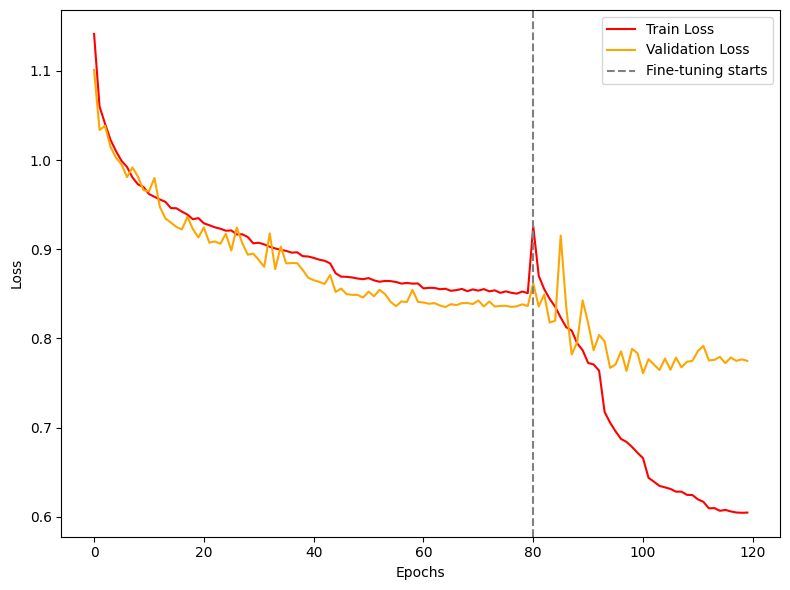

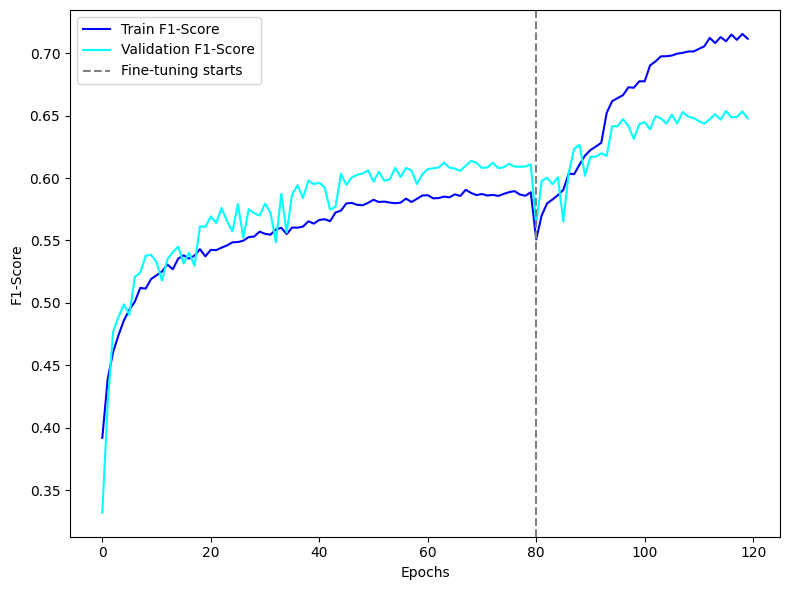

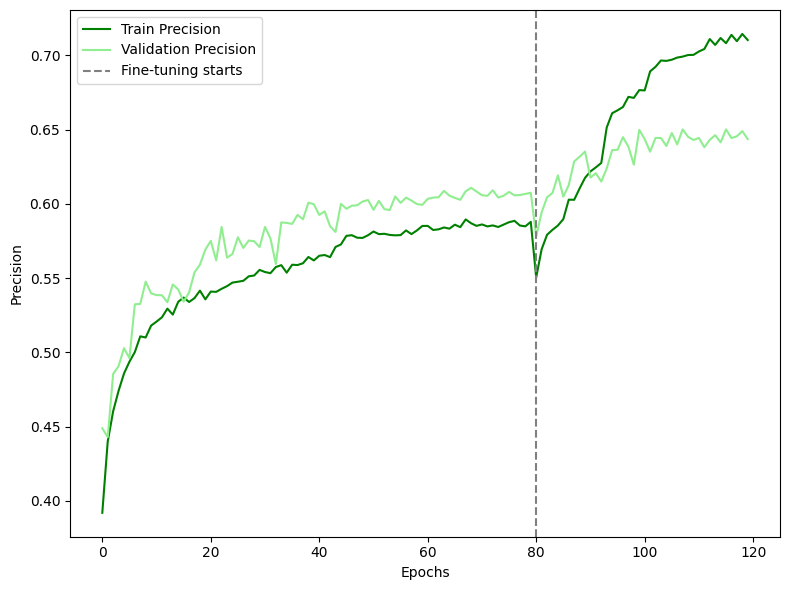

done1


In [17]:
# ==========================================================
# PLOT LEARNING CURVES (Loss, F1-Score, Precision)
# ==========================================================
print("start")

def concat_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

phase1_end = len(history.history['loss'])

plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'loss'), label='Train Loss', color='red')
plt.plot(concat_history(history, history_finetune, 'val_loss'), label='Validation Loss', color='orange')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout()
plt.savefig("LateFusion_Loss_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'f1_score'), label='Train F1-Score', color='blue')
plt.plot(concat_history(history, history_finetune, 'val_f1_score'), label='Validation F1-Score', color='cyan')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.tight_layout()
plt.savefig("LateFusion_F1_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(concat_history(history, history_finetune, 'precision'), label='Train Precision', color='green')
plt.plot(concat_history(history, history_finetune, 'val_precision'), label='Validation Precision', color='lightgreen')
plt.axvline(phase1_end, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.tight_layout()
plt.savefig("LateFusion_Precision_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")


In [18]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
print("Evaluating on Training Set...")
train_results = model.evaluate(train_generator)

print("\nEvaluating on Validation Set...")
val_results = model.evaluate(val_generator)

print("\nEvaluating on Testing Set (Truly Unseen)...")
test_results = model.evaluate(test_generator)

train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

print("\n" + "="*40)
print("TRAINING METRICS")
print("="*40)
print(f"Training Loss      : {train_loss:.4f}")
print(f"Training Accuracy  : {train_acc*100:.2f}%")
print(f"Training F1-Score  : {train_f1*100:.2f}%")
print(f"Training Precision : {train_precision*100:.2f}%")
print(f"Training Recall    : {train_recall*100:.2f}%")

print("\n" + "="*40)
print("VALIDATION METRICS")
print("="*40)
print(f"Validation Loss      : {val_loss:.4f}")
print(f"Validation Accuracy  : {val_acc*100:.2f}%")
print(f"Validation F1-Score  : {val_f1*100:.2f}%")
print(f"Validation Precision : {val_precision*100:.2f}%")
print(f"Validation Recall    : {val_recall*100:.2f}%")

print("\n" + "="*40)
print("TESTING METRICS (UNSEEN DATA)")
print("="*40)
print(f"Testing Loss      : {test_loss:.4f}")
print(f"Testing Accuracy  : {test_acc*100:.2f}%")
print(f"Testing F1-Score  : {test_f1*100:.2f}%")
print(f"Testing Precision : {test_precision*100:.2f}%")
print(f"Testing Recall    : {test_recall*100:.2f}%")


Evaluating on Training Set...
563/563 [==============================] - 246s 436ms/step - loss: 0.5902 - accuracy: 0.7281 - f1_score: 0.7128 - precision: 0.7124 - recall: 0.7181

Evaluating on Validation Set...
93/93 [==============================] - 43s 457ms/step - loss: 0.7723 - accuracy: 0.6530 - f1_score: 0.6537 - precision: 0.6502 - recall: 0.6604

Evaluating on Testing Set (Truly Unseen)...
92/92 [==============================] - 44s 478ms/step - loss: 0.7686 - accuracy: 0.6538 - f1_score: 0.6522 - precision: 0.6494 - recall: 0.6560

TRAINING METRICS
Training Loss      : 0.5902
Training Accuracy  : 72.81%
Training F1-Score  : 71.28%
Training Precision : 71.24%
Training Recall    : 71.81%

VALIDATION METRICS
Validation Loss      : 0.7723
Validation Accuracy  : 65.30%
Validation F1-Score  : 65.37%
Validation Precision : 65.02%
Validation Recall    : 66.04%

TESTING METRICS (UNSEEN DATA)
Testing Loss      : 0.7686
Testing Accuracy  : 65.38%
Testing F1-Score  : 65.22%
Testing Pre

In [19]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nCalculating Precision, Recall, F1-score on Test Set...")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = test_generator.class_names

print("\nClassification Report (Test Set):\n")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

print("done1")



Calculating Precision, Recall, F1-score on Test Set...
92/92 [==============================] - 40s 425ms/step

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.53      0.50      0.52       888
   Malignant       0.68      0.67      0.67      1266
      Normal       0.74      0.79      0.77       789

    accuracy                           0.65      2943
   macro avg       0.65      0.66      0.65      2943
weighted avg       0.65      0.65      0.65      2943

done1


Generating Confusion Matrix...


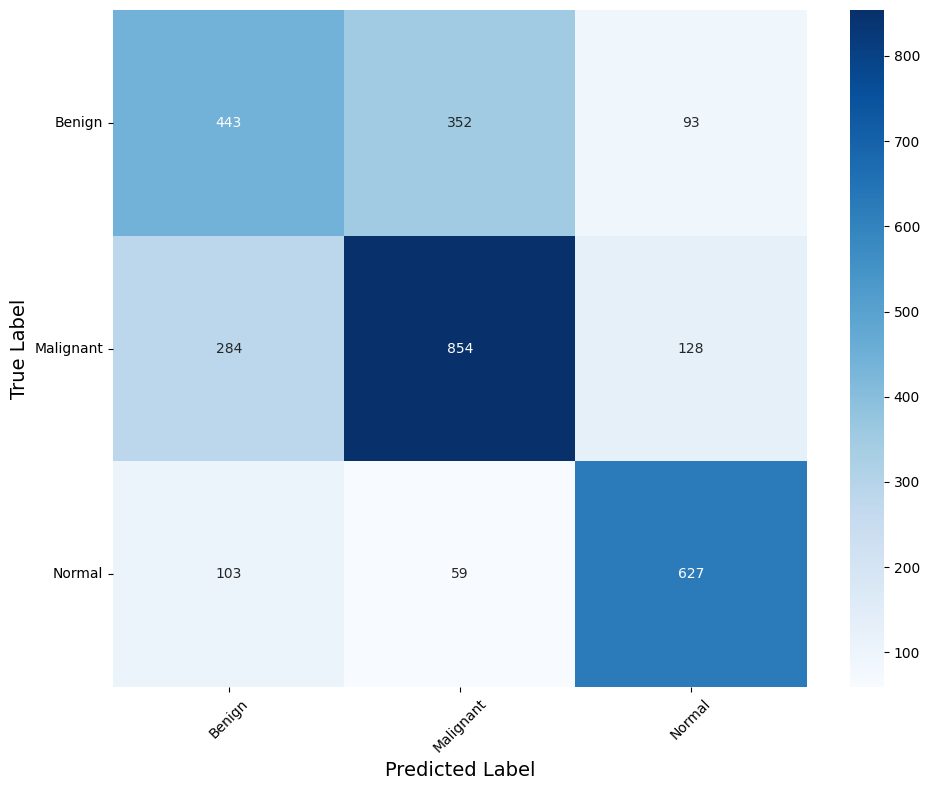

done1


In [20]:
# ==========================================================
# CONFUSION MATRIX (Test Set)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("LateFusion_confusion_matrix_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")
